# Calibration Cox

**This notebook assesses calibration performance of the Cox model and recalibrates predictions using isotonic regression for patients with MSI-H metastatic colorectal cancer receiving first-line pembrolizumab or chemotherapy.**

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from scipy.stats import linregress
from sklearn.model_selection import StratifiedKFold
from joblib import Parallel, delayed
from sklearn.isotonic import IsotonicRegression
from sksurv.metrics import brier_score

from utils.calibration import calculate_calibration_curve, calibrate_survival_predictions

## Import Data

In [2]:
survival_predictions_df = pd.read_csv('../outputs/cox_survival_predictions.csv')

In [3]:
survival_predictions_df = survival_predictions_df[['PatientID', 'risk_score', 'psurv_180']]

In [4]:
survival_predictions_df.shape

(37381, 3)

In [5]:
dtype_map = pd.read_csv('../outputs/pembro_chemo_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
pembro_pembrochemo_df = pd.read_csv('../outputs/pembro_chemo_features_df.csv', dtype = dtype_map)

In [6]:
pembro_pembrochemo_df.shape

(1208, 170)

In [7]:
df = pd.merge(pembro_pembrochemo_df, survival_predictions_df, on = 'PatientID', how = 'left')

In [8]:
df.shape

(1208, 172)

In [9]:
df = df.query('met_diagnosis_year <= 2023')

In [10]:
df.shape

(1074, 172)

## Raw Calibration Assessment

In [11]:
cal_df = calculate_calibration_curve(df, 'psurv_180', 180)

In [12]:
cal_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(0.0848, 0.794]",0.703432,0.483924,108,0.385270,0.575604
1,"(0.794, 0.839]",0.820169,0.613374,107,0.508107,0.693244
2,"(0.839, 0.861]",0.849984,0.789392,107,0.689530,0.849435
3,"(0.861, 0.879]",0.870588,0.856811,108,0.767126,0.906512
4,"(0.879, 0.893]",0.885696,0.854780,107,0.760985,0.903038
5,"(0.893, 0.903]",0.898473,0.867231,107,0.786108,0.919140
6,"(0.903, 0.915]",0.908666,0.873977,108,0.792810,0.924825
7,"(0.915, 0.925]",0.920017,0.932740,107,0.854746,0.962457
8,"(0.925, 0.938]",0.931597,0.961344,107,0.899908,0.985150
9,"(0.938, 0.996]",0.949654,0.990476,108,0.933988,0.998515


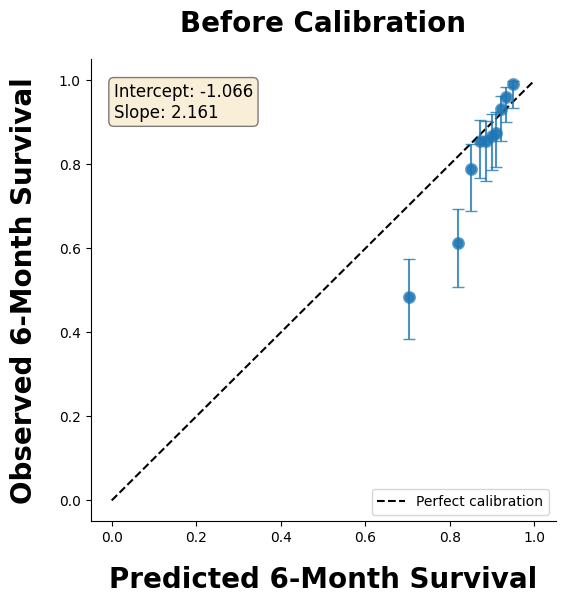

In [13]:
slope_orig, intercept_orig, _, _, _ = linregress(
    cal_df['predicted'], 
    cal_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_df['predicted'], cal_df['observed'], s = 70, alpha = 0.6)
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_df['observed'] - cal_df['obs_lo'],
    cal_df['obs_hi'] - cal_df['observed']
])

plt.errorbar(
    cal_df['predicted'],
    cal_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,    
    capsize = 4,         
    alpha = 0.8
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_orig:.3f}\nSlope: {slope_orig:.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 12, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.title('Before Calibration',  weight = 'bold', size = 20, pad = 20)
plt.legend()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

## Isotonic Calibration Using Cross Validation 

In [14]:
# Prepare structured array for survival outcomes
y_dtype = [('event', bool), ('duration', float)]

y = np.array([tuple(x) for x in df[['event', 'duration']].values],
             dtype = y_dtype)

In [15]:
df, brier_scores = calibrate_survival_predictions(df, y, 'psurv_180', 180)


=== Fold 1/5 ===
Brier score at 180 days (calibrated): 0.1344

=== Fold 2/5 ===
Brier score at 180 days (calibrated): 0.1231

=== Fold 3/5 ===
Brier score at 180 days (calibrated): 0.1223

=== Fold 4/5 ===
Brier score at 180 days (calibrated): 0.1253

=== Fold 5/5 ===
Brier score at 180 days (calibrated): 0.1185

=== Summary ===
psurv_180_calibrated computed: 1074

=== Brier Scores at 180 days (calibrated) ===
Mean: 0.1247 ± 0.0053


In [16]:
df_final_calibrated = df[['PatientID', 'psurv_180_calibrated']]

In [17]:
df_final_calibrated.to_csv('../outputs/cox_6m_survival_predictions_calibrated.csv', index = False)

In [18]:
cal_iso_df = calculate_calibration_curve(df, 'psurv_180_calibrated', 180)

In [19]:
cal_iso_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(0.388, 0.585]",0.462588,0.526897,109,0.427476,0.616872
1,"(0.585, 0.63]",0.616975,0.612114,117,0.513460,0.690459
2,"(0.63, 0.847]",0.801933,0.799558,129,0.710691,0.854312
3,"(0.847, 0.851]",0.849623,0.852071,110,0.763591,0.902176
4,"(0.851, 0.867]",0.863060,0.872093,86,0.780952,0.927041
5,"(0.867, 0.888]",0.878031,0.848539,112,0.754896,0.897468
6,"(0.888, 0.912]",0.896839,0.894205,107,0.817056,0.939991
7,"(0.912, 0.945]",0.935006,0.931058,91,0.844955,0.964313
8,"(0.945, 0.982]",0.966631,0.954861,114,0.894487,0.980742
9,"(0.982, 1.0]",0.999123,0.989583,99,0.927995,0.998375


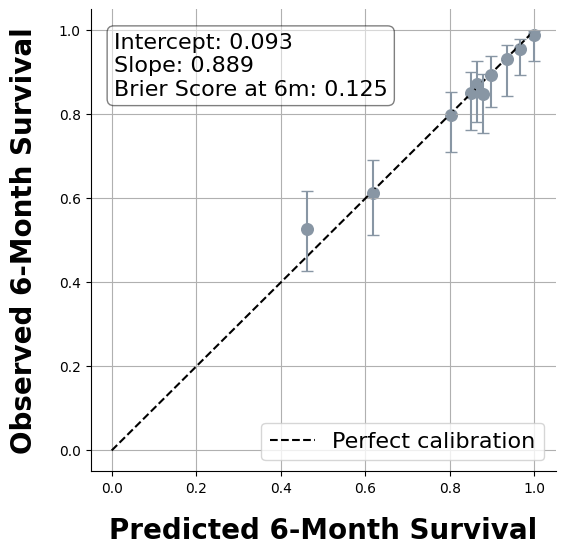

In [20]:
slope_iso, intercept_iso, _, _, _ = linregress(
    cal_iso_df['predicted'], 
    cal_iso_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_iso_df['predicted'], cal_iso_df['observed'], s = 70, color='#8896A4')
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_iso_df['observed'] - cal_iso_df['obs_lo'],
    cal_iso_df['obs_hi'] - cal_iso_df['observed']
])

plt.errorbar(
    cal_iso_df['predicted'],
    cal_iso_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,
    color = '#8896A4',
    capsize = 4
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_iso:.3f}\nSlope: {slope_iso:.3f}\nBrier Score at 6m: {np.mean(brier_scores):.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 16, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
#plt.title('After Isotonic Regression',  weight = 'bold', size = 20, pad = 20)
plt.legend(fontsize=16)
plt.grid(True)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()